# DeepPCB Defect Detection with YOLOv11s

This notebook trains a **YOLOv11s** model on the **DeepPCB** dataset (Roboflow YOLOv11 format) for PCB defect detection.

**Dataset:** Train 1050 / Valid 150 / Test 300 images

**Pipeline:**
1. Environment setup
2. Dataset inspection & visualization (images + bounding boxes + class distribution)
3. Data augmentation tuned for PCB defects
4. Training YOLOv11s with early stopping + target mAP@50 stop
5. Evaluation on test set + inference visualization

## 1. Setup & Imports

In [1]:
# Install Ultralytics (YOLOv11) if not already installed
!pip install -q ultralytics pyyaml matplotlib seaborn pandas opencv-python

In [2]:
import os
import glob
import yaml
import random
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

import torch
from ultralytics import YOLO

print('Torch:', torch.__version__, '| CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

Torch: 2.8.0+cu128 | CUDA available: True
GPU: Tesla T4


In [ ]:
# ---- CONFIG ----
# Adjust DATASET_DIR to where you placed the Roboflow export
DATASET_DIR = Path('deepPCB')        # root folder containing data.yaml + train/valid/test
DATA_YAML   = DATASET_DIR / 'data.yaml'

TRAIN_IMG_DIR = DATASET_DIR / 'train' / 'images'
TRAIN_LBL_DIR = DATASET_DIR / 'train' / 'labels'
VAL_IMG_DIR   = DATASET_DIR / 'valid' / 'images'
VAL_LBL_DIR   = DATASET_DIR / 'valid' / 'labels'
TEST_IMG_DIR  = DATASET_DIR / 'test'  / 'images'
TEST_LBL_DIR  = DATASET_DIR / 'test'  / 'labels'

assert DATA_YAML.exists(), f'data.yaml not found at {DATA_YAML}'

with open(DATA_YAML, 'r') as f:
    data_cfg = yaml.safe_load(f)
print('data.yaml contents:')
print(yaml.dump(data_cfg, sort_keys=False))

CLASS_NAMES = data_cfg['names'] if isinstance(data_cfg['names'], list) else list(data_cfg['names'].values())
NUM_CLASSES = len(CLASS_NAMES)
print(f'Classes ({NUM_CLASSES}):', CLASS_NAMES)

data.yaml contents:
train: ../train/images
val: ../valid/images
test: ../test/images
nc: 6
names:
- copper
- mousebite
- open
- pin-hole
- short
- spur
roboflow:
  workspace: tack-hwa-wong-zak5u
  project: deeppcb-4dhir
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/tack-hwa-wong-zak5u/deeppcb-4dhir/dataset/1

Classes (6): ['copper', 'mousebite', 'open', 'pin-hole', 'short', 'spur']


## 2. Dataset Inspection & Visualization

Image counts: {'train': 1050, 'valid': 150, 'test': 300}


/tmp/ipykernel_3931/2175197424.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(split_counts.keys()), y=list(split_counts.values()), palette='viridis')


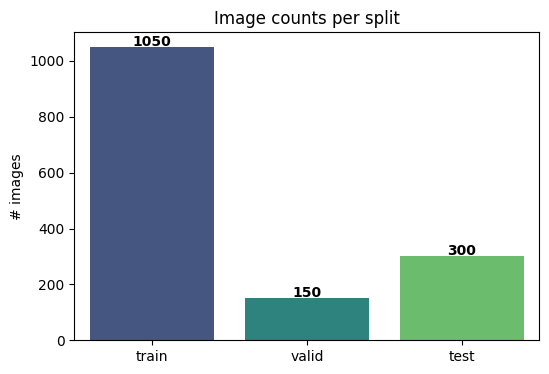

In [ ]:
def count_imgs(p):
    return len(glob.glob(str(p / '*.jpg'))) + len(glob.glob(str(p / '*.png'))) + len(glob.glob(str(p / '*.jpeg')))

split_counts = {
    'train': count_imgs(TRAIN_IMG_DIR),
    'valid': count_imgs(VAL_IMG_DIR),
    'test':  count_imgs(TEST_IMG_DIR),
}
print('Image counts:', split_counts)

plt.figure(figsize=(6, 4))
sns.barplot(x=list(split_counts.keys()), y=list(split_counts.values()), palette='viridis')
plt.title('Image counts per split')
plt.ylabel('# images')
for i, v in enumerate(split_counts.values()):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.show()

       class  train  valid
0     copper   1034    138
1  mousebite   1373    188
2       open   1360    193
3   pin-hole   1042    149
4      short   1068    147
5       spur   1132    178


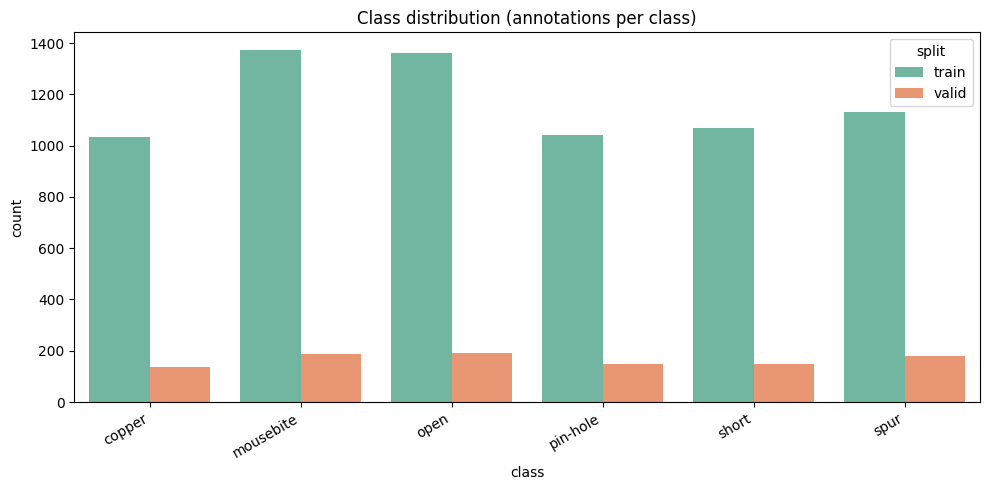

In [ ]:
# Class distribution across the training split
def collect_class_counts(label_dir):
    counts = Counter()
    for lbl in glob.glob(str(label_dir / '*.txt')):
        with open(lbl, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if not parts:
                    continue
                cls_id = int(parts[0])
                counts[cls_id] += 1
    return counts

train_counts = collect_class_counts(TRAIN_LBL_DIR)
val_counts   = collect_class_counts(VAL_LBL_DIR)

df = pd.DataFrame({
    'class': [CLASS_NAMES[i] for i in range(NUM_CLASSES)],
    'train': [train_counts.get(i, 0) for i in range(NUM_CLASSES)],
    'valid': [val_counts.get(i, 0)   for i in range(NUM_CLASSES)],
})
print(df)

df_m = df.melt(id_vars='class', var_name='split', value_name='count')
plt.figure(figsize=(10, 5))
sns.barplot(data=df_m, x='class', y='count', hue='split', palette='Set2')
plt.title('Class distribution (annotations per class)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

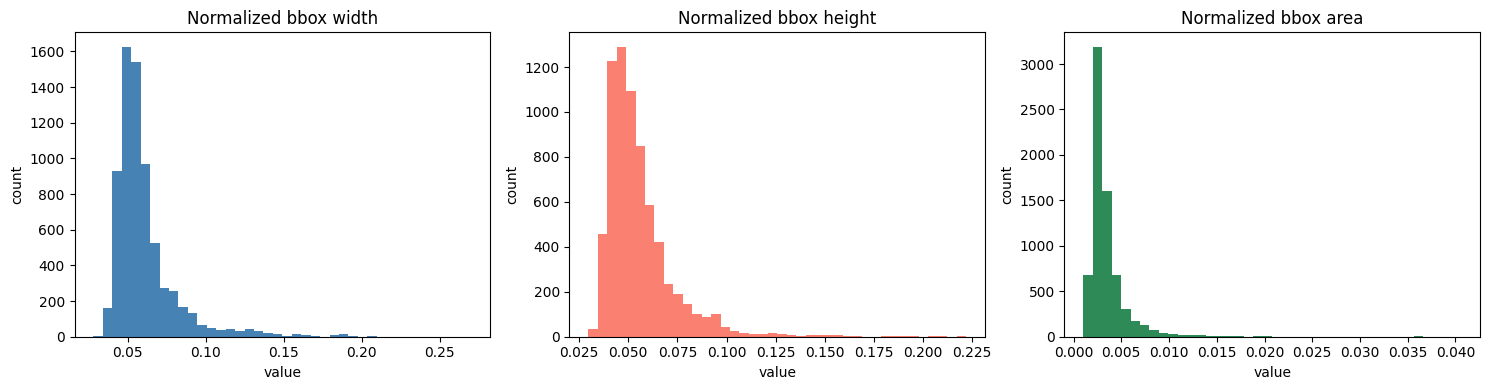

Median bbox area: 0.00289  (small values => tiny defects, anchor-free YOLO11 handles them well)


In [6]:
# Bounding-box size distribution (defects in PCBs tend to be small — good to confirm)
def collect_bbox_sizes(label_dir):
    ws, hs, areas = [], [], []
    for lbl in glob.glob(str(label_dir / '*.txt')):
        with open(lbl, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                _, _, _, w, h = parts[:5]
                w, h = float(w), float(h)
                ws.append(w); hs.append(h); areas.append(w * h)
    return np.array(ws), np.array(hs), np.array(areas)

ws, hs, areas = collect_bbox_sizes(TRAIN_LBL_DIR)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(ws, bins=40, color='steelblue'); axes[0].set_title('Normalized bbox width')
axes[1].hist(hs, bins=40, color='salmon');    axes[1].set_title('Normalized bbox height')
axes[2].hist(areas, bins=40, color='seagreen');axes[2].set_title('Normalized bbox area')
for ax in axes: ax.set_xlabel('value'); ax.set_ylabel('count')
plt.tight_layout(); plt.show()

print(f'Median bbox area: {np.median(areas):.5f}  (small values => tiny defects, anchor-free YOLO11 handles them well)')

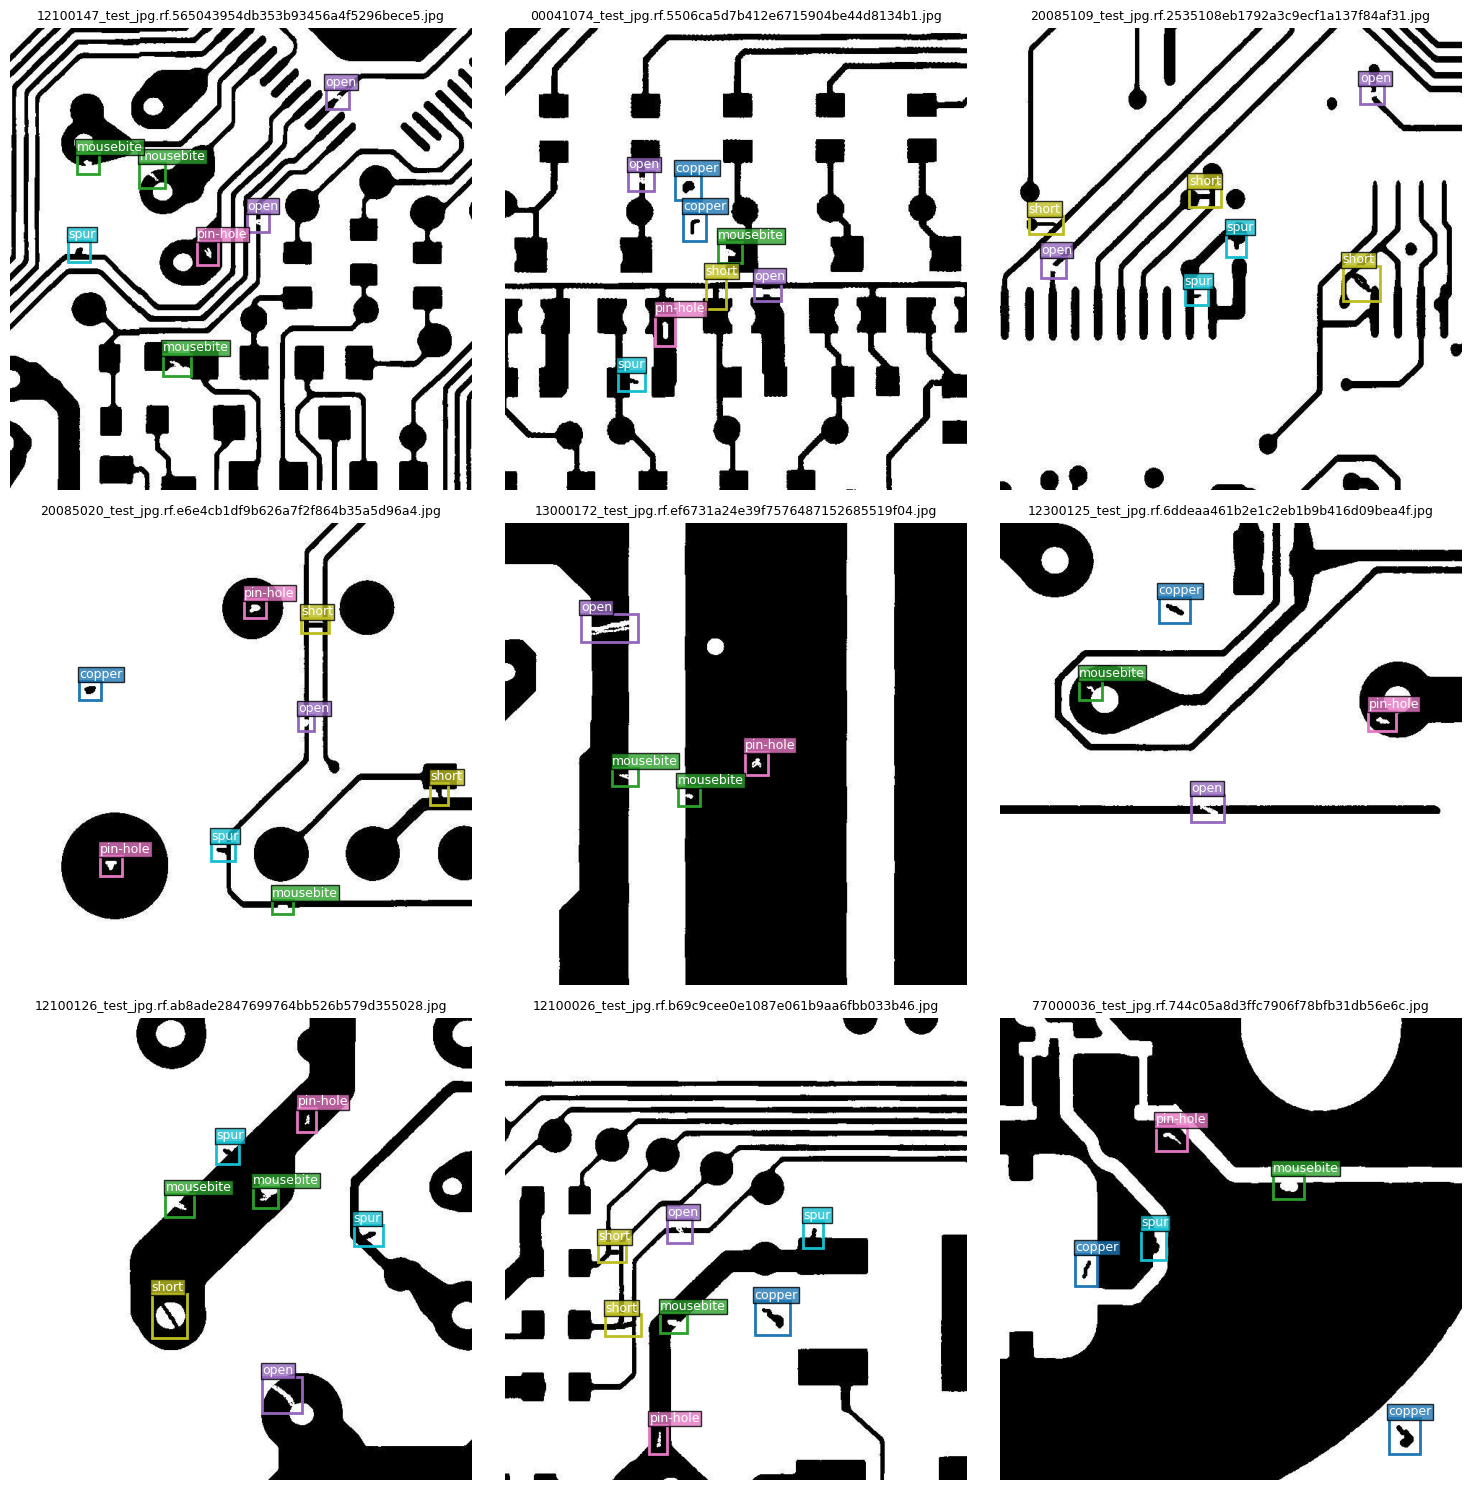

In [ ]:
# Visualize sample images with bounding boxes
def yolo_to_xyxy(box, W, H):
    cx, cy, w, h = box
    x1 = (cx - w / 2) * W
    y1 = (cy - h / 2) * H
    x2 = (cx + w / 2) * W
    y2 = (cy + h / 2) * H
    return x1, y1, x2, y2

def show_sample(img_dir, lbl_dir, n=9):
    files = sorted(glob.glob(str(img_dir / '*.jpg')) + glob.glob(str(img_dir / '*.png')))
    sample = random.sample(files, min(n, len(files)))
    cols = 3
    rows = (len(sample) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 5))
    axes = np.array(axes).reshape(-1)
    colors = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))
    for ax, img_path in zip(axes, sample):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        H, W = img.shape[:2]
        ax.imshow(img)
        lbl_path = Path(lbl_dir) / (Path(img_path).stem + '.txt')
        if lbl_path.exists():
            with open(lbl_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) < 5: continue
                    cls = int(parts[0])
                    x1, y1, x2, y2 = yolo_to_xyxy(list(map(float, parts[1:5])), W, H)
                    rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                              linewidth=2, edgecolor=colors[cls % NUM_CLASSES], facecolor='none')
                    ax.add_patch(rect)
                    ax.text(x1, y1 - 4, CLASS_NAMES[cls], color='white', fontsize=9,
                            bbox=dict(facecolor=colors[cls % NUM_CLASSES], alpha=0.8, pad=1))
        ax.set_title(Path(img_path).name, fontsize=9)
        ax.axis('off')
    for ax in axes[len(sample):]:
        ax.axis('off')
    plt.tight_layout(); plt.show()

show_sample(TRAIN_IMG_DIR, TRAIN_LBL_DIR, n=9)

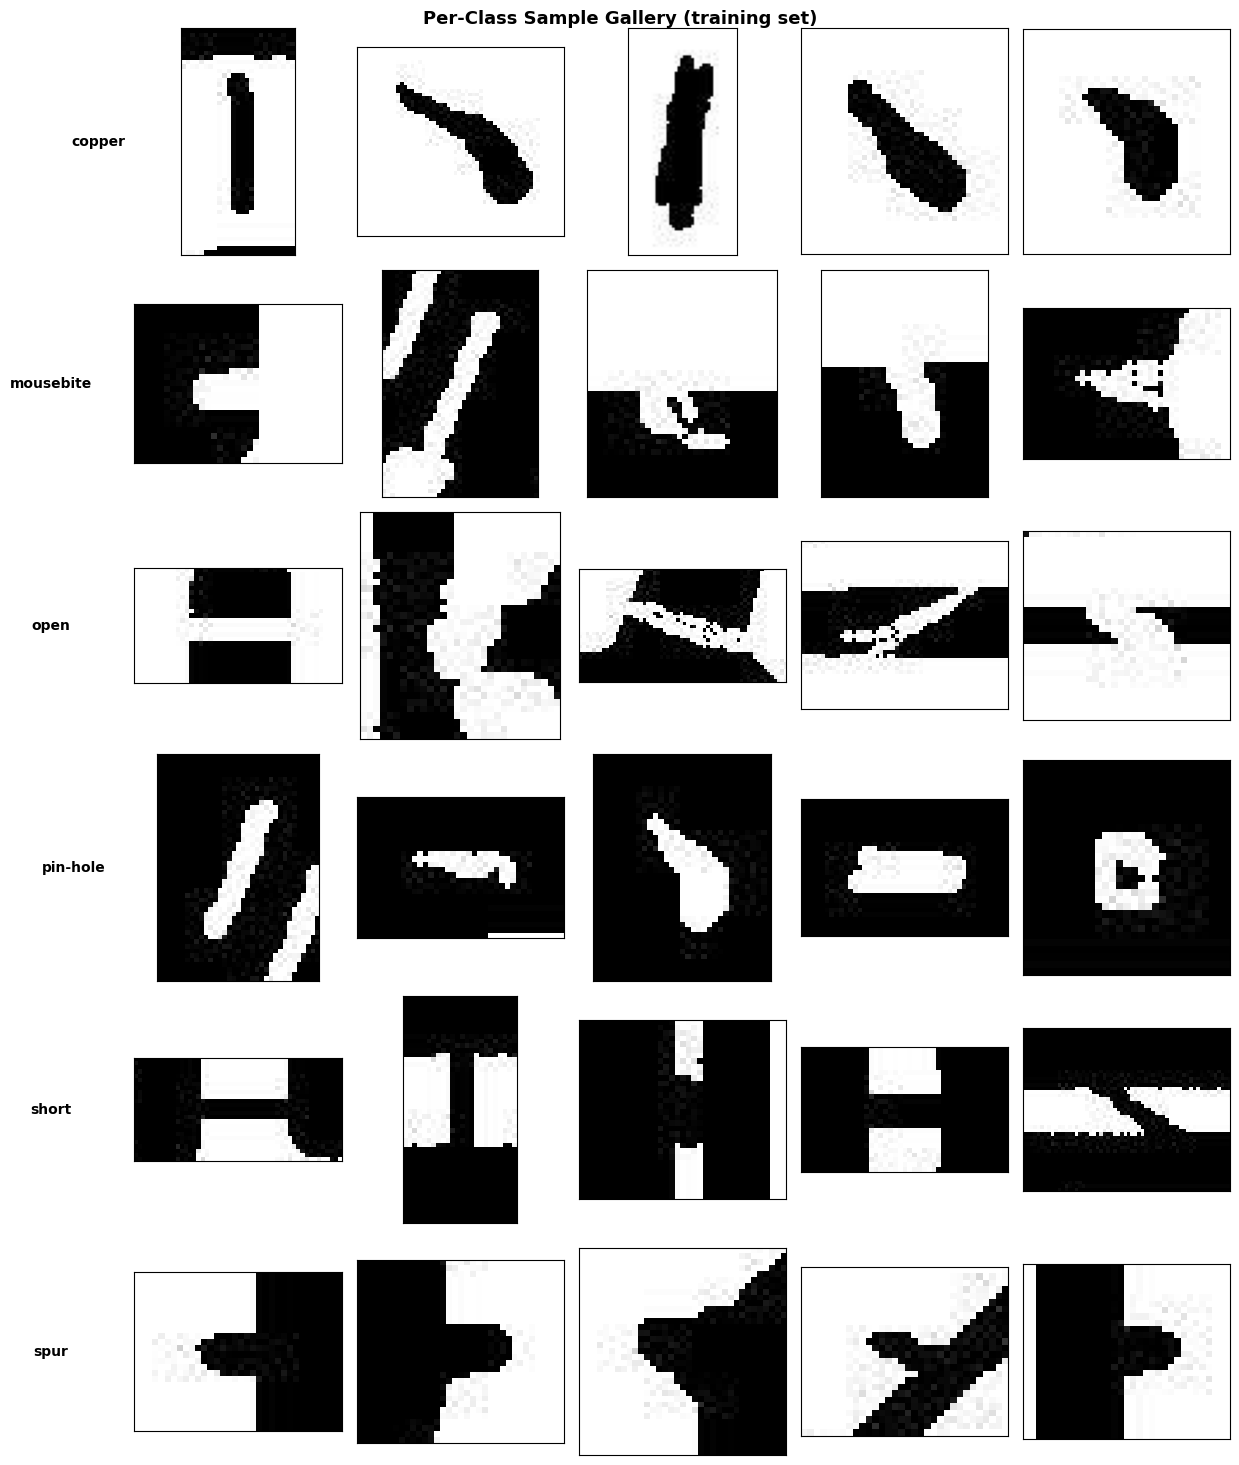

In [8]:
# --- EDA 1: Per-class sample gallery ---
# Shows example image crops for each defect class to verify label correctness

def show_class_gallery(img_dir, lbl_dir, class_names, n_per_class=5):
    class_samples = {i: [] for i in range(len(class_names))}
    label_files = glob.glob(str(lbl_dir / '*.txt'))

    for lbl_path in label_files:
        img_path = img_dir / (Path(lbl_path).stem + '.jpg')
        if not img_path.exists():
            img_path = img_dir / (Path(lbl_path).stem + '.png')
        if not img_path.exists():
            continue
        img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
        H, W = img.shape[:2]
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                cls = int(parts[0])
                cx, cy, w, h = map(float, parts[1:5])
                x1 = max(0, int((cx - w / 2) * W))
                y1 = max(0, int((cy - h / 2) * H))
                x2 = min(W, int((cx + w / 2) * W))
                y2 = min(H, int((cy + h / 2) * H))
                crop = img[y1:y2, x1:x2]
                if crop.size == 0:
                    continue
                if len(class_samples[cls]) < n_per_class:
                    class_samples[cls].append(crop)

    n_classes = len(class_names)
    fig, axes = plt.subplots(n_classes, n_per_class, figsize=(n_per_class * 2.5, n_classes * 2.5))
    if n_classes == 1:
        axes = [axes]
    for r, (cls_id, crops) in enumerate(class_samples.items()):
        for c in range(n_per_class):
            ax = axes[r][c]
            if c < len(crops):
                ax.imshow(crops[c])
            else:
                ax.set_facecolor('#222')
            if c == 0:
                ax.set_ylabel(class_names[cls_id], fontsize=10, fontweight='bold', rotation=0,
                              labelpad=60, va='center')
            ax.set_xticks([]); ax.set_yticks([])
    plt.suptitle('Per-Class Sample Gallery (training set)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_class_gallery(TRAIN_IMG_DIR, TRAIN_LBL_DIR, CLASS_NAMES, n_per_class=5)

Train: mean=6.68, median=7.0, max=15, zero-label images=0
Val: mean=6.62, median=6.5, max=12, zero-label images=0


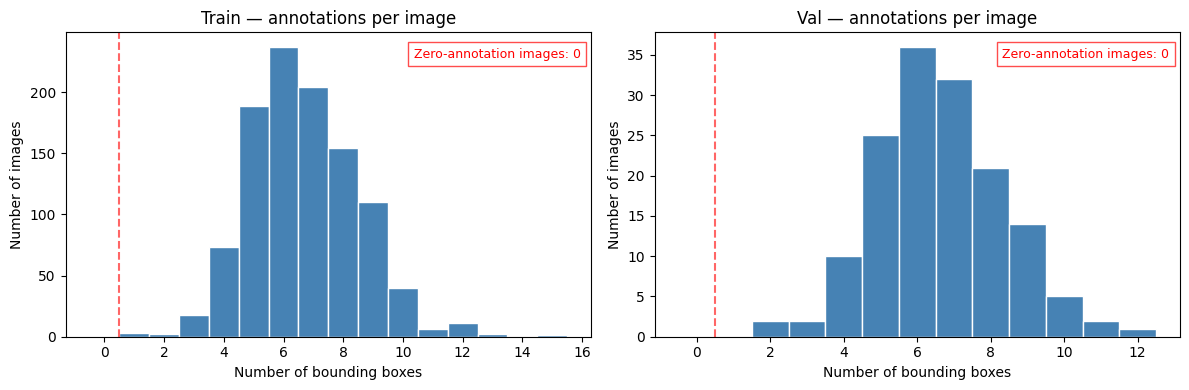

In [9]:
# --- EDA 2: Annotations-per-image distribution ---
# Reveals over-annotated images and how many images have zero defects

def annotations_per_image(label_dir):
    counts = []
    for lbl in glob.glob(str(label_dir / '*.txt')):
        with open(lbl) as f:
            lines = [l for l in f if l.strip()]
        counts.append(len(lines))
    return counts

train_ann_counts = annotations_per_image(TRAIN_LBL_DIR)
val_ann_counts   = annotations_per_image(VAL_LBL_DIR)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, counts, split in zip(axes, [train_ann_counts, val_ann_counts], ['Train', 'Val']):
    ax.hist(counts, bins=range(0, max(counts) + 2), color='steelblue', edgecolor='white', align='left')
    ax.set_title(f'{split} — annotations per image')
    ax.set_xlabel('Number of bounding boxes')
    ax.set_ylabel('Number of images')
    zero_count = counts.count(0)
    ax.axvline(0.5, color='red', linestyle='--', alpha=0.6)
    ax.text(0.98, 0.95, f'Zero-annotation images: {zero_count}',
            transform=ax.transAxes, ha='right', va='top',
            color='red', fontsize=9,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='red'))
    print(f'{split}: mean={np.mean(counts):.2f}, median={np.median(counts):.1f}, '
          f'max={max(counts)}, zero-label images={zero_count}')
plt.tight_layout()
plt.show()

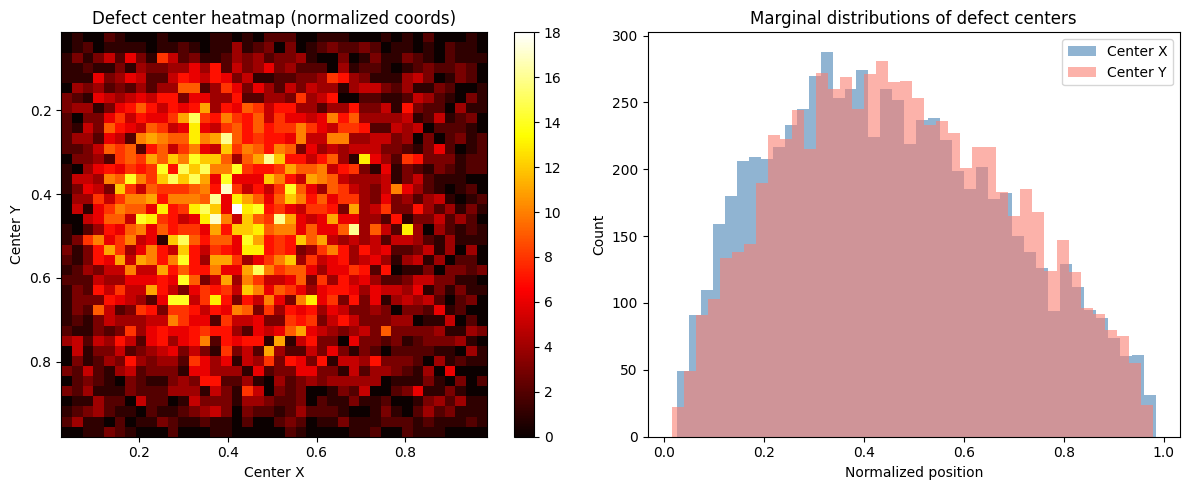

Total annotations plotted: 7009


In [10]:
# --- EDA 3: Defect spatial heatmap ---
# Shows WHERE defects appear on the image canvas — informs crop/augmentation strategy

def collect_centers(label_dir):
    cxs, cys = [], []
    for lbl in glob.glob(str(label_dir / '*.txt')):
        with open(lbl) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                _, cx, cy, _, _ = parts[:5]
                cxs.append(float(cx))
                cys.append(float(cy))
    return np.array(cxs), np.array(cys)

cxs, cys = collect_centers(TRAIN_LBL_DIR)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 2D histogram heatmap
h = axes[0].hist2d(cxs, cys, bins=40, cmap='hot')
plt.colorbar(h[3], ax=axes[0])
axes[0].set_title('Defect center heatmap (normalized coords)')
axes[0].set_xlabel('Center X'); axes[0].set_ylabel('Center Y')
axes[0].invert_yaxis()  # image origin is top-left

# Marginal distributions
axes[1].hist(cxs, bins=40, alpha=0.6, label='Center X', color='steelblue')
axes[1].hist(cys, bins=40, alpha=0.6, label='Center Y', color='salmon')
axes[1].set_title('Marginal distributions of defect centers')
axes[1].set_xlabel('Normalized position'); axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f'Total annotations plotted: {len(cxs)}')

         copper: median ratio = 1.000, n = 1034
      mousebite: median ratio = 1.133, n = 1373
           open: median ratio = 1.138, n = 1360
       pin-hole: median ratio = 1.024, n = 1042
          short: median ratio = 1.226, n = 1068
           spur: median ratio = 1.071, n = 1132


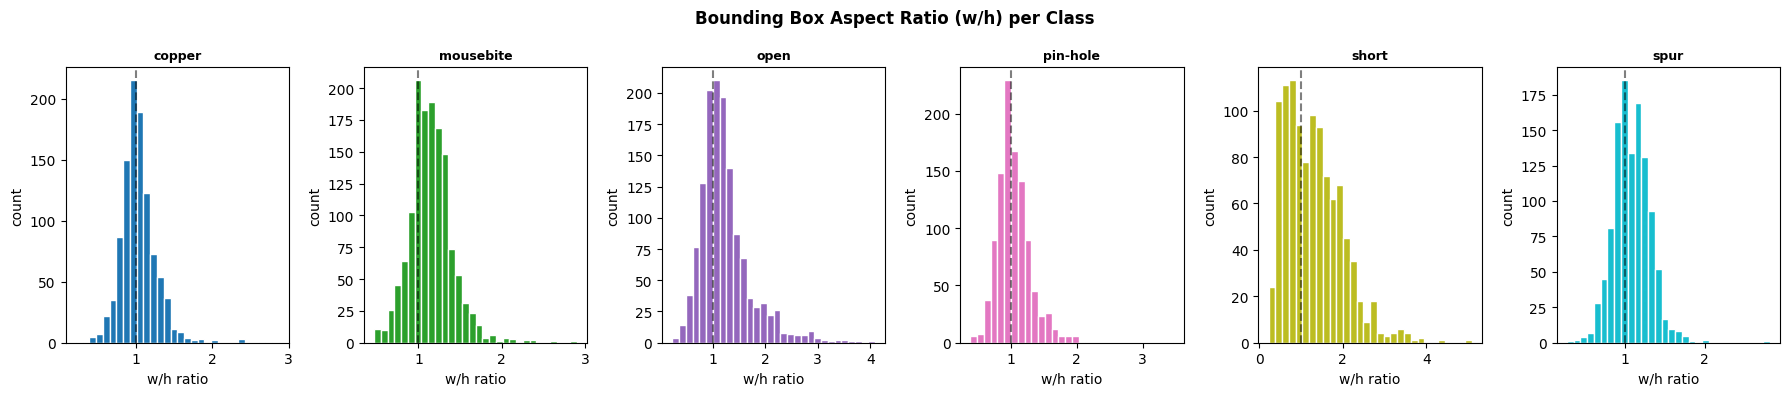

In [11]:
# --- EDA 4: Bounding-box aspect ratio per class ---
# Elongated defects (opens) vs blob defects (shorts) have very different w/h ratios

def collect_aspect_ratios_by_class(label_dir, n_classes):
    ratios = {i: [] for i in range(n_classes)}
    for lbl in glob.glob(str(label_dir / '*.txt')):
        with open(lbl) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                cls = int(parts[0])
                w, h = float(parts[3]), float(parts[4])
                if h > 0:
                    ratios[cls].append(w / h)
    return ratios

aspect_ratios = collect_aspect_ratios_by_class(TRAIN_LBL_DIR, NUM_CLASSES)

fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(NUM_CLASSES * 3, 4), sharey=False)
if NUM_CLASSES == 1:
    axes = [axes]
colors = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))

for i, (ax, color) in enumerate(zip(axes, colors)):
    data = aspect_ratios[i]
    if data:
        ax.hist(data, bins=30, color=color, edgecolor='white')
        ax.axvline(1.0, color='black', linestyle='--', alpha=0.5, label='square')
        ax.set_title(CLASS_NAMES[i], fontsize=9, fontweight='bold')
        ax.set_xlabel('w/h ratio')
        ax.set_ylabel('count')
        print(f'{CLASS_NAMES[i]:>15}: median ratio = {np.median(data):.3f}, '
              f'n = {len(data)}')
    else:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                transform=ax.transAxes)

plt.suptitle('Bounding Box Aspect Ratio (w/h) per Class', fontweight='bold')
plt.tight_layout()
plt.show()

    class  train  valid  test
   copper   1034    138   302
mousebite   1373    188   404
     open   1360    193   389
 pin-hole   1042    149   310
    short   1068    147   291
     spur   1132    178   315


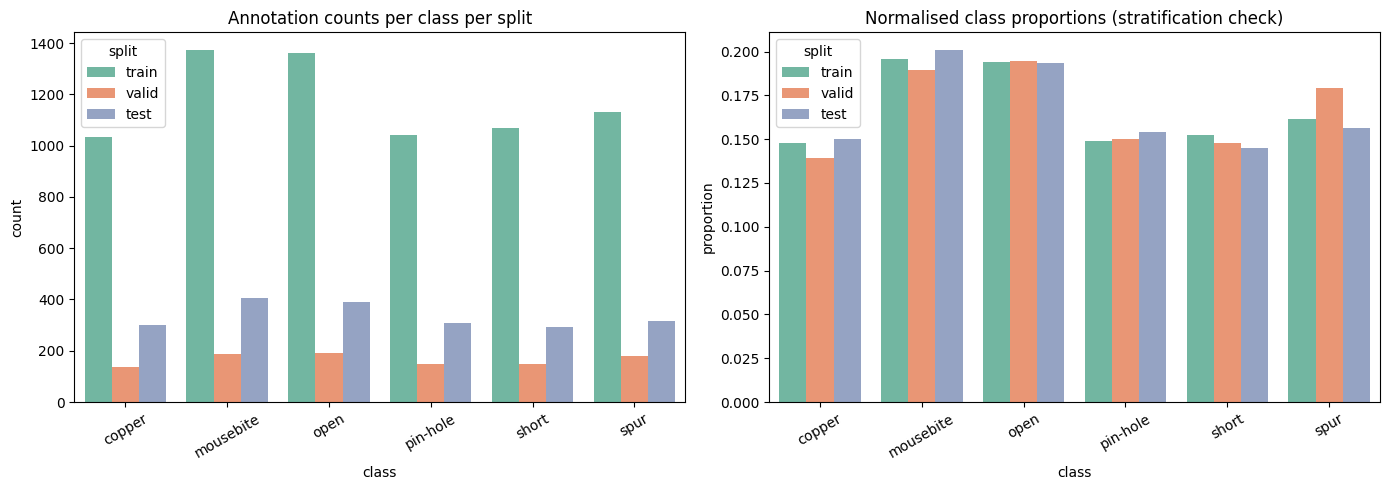

In [12]:
# --- EDA 5: Class distribution including test split ---
# Confirms the train/val/test split is well-stratified across all defect classes

test_counts = collect_class_counts(TEST_LBL_DIR)   # reuses helper from existing EDA

df_full = pd.DataFrame({
    'class': [CLASS_NAMES[i] for i in range(NUM_CLASSES)],
    'train': [train_counts.get(i, 0) for i in range(NUM_CLASSES)],
    'valid': [val_counts.get(i, 0)   for i in range(NUM_CLASSES)],
    'test':  [test_counts.get(i, 0)  for i in range(NUM_CLASSES)],
})
print(df_full.to_string(index=False))

# Normalised proportions to check stratification
df_norm = df_full.copy()
for col in ['train', 'valid', 'test']:
    total = df_norm[col].sum()
    df_norm[col] = df_norm[col] / total if total > 0 else 0

df_m = df_full.melt(id_vars='class', var_name='split', value_name='count')
df_norm_m = df_norm.melt(id_vars='class', var_name='split', value_name='proportion')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=df_m, x='class', y='count', hue='split',
            palette='Set2', ax=axes[0])
axes[0].set_title('Annotation counts per class per split')
axes[0].tick_params(axis='x', rotation=30)

sns.barplot(data=df_norm_m, x='class', y='proportion', hue='split',
            palette='Set2', ax=axes[1])
axes[1].set_title('Normalised class proportions (stratification check)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [13]:
# --- EDA 6: Label sanity check ---
# Catches corrupted/malformed annotations that silently degrade training

def label_sanity_check(label_dir, img_dir, n_classes):
    issues = []
    total_files = 0

    for lbl_path in glob.glob(str(label_dir / '*.txt')):
        total_files += 1
        stem = Path(lbl_path).stem

        # Check corresponding image exists
        img_exists = any((img_dir / f'{stem}{ext}').exists()
                         for ext in ['.jpg', '.png', '.jpeg'])
        if not img_exists:
            issues.append({'file': stem, 'issue': 'missing image'})

        with open(lbl_path) as f:
            lines = [l.strip() for l in f if l.strip()]

        if len(lines) == 0:
            issues.append({'file': stem, 'issue': 'zero annotations'})
            continue

        for line in lines:
            parts = line.split()
            # Malformed: not enough fields
            if len(parts) < 5:
                issues.append({'file': stem, 'issue': f'malformed line: "{line}"'})
                continue
            try:
                cls = int(parts[0])
                cx, cy, w, h = map(float, parts[1:5])
            except ValueError:
                issues.append({'file': stem, 'issue': f'non-numeric values: "{line}"'})
                continue

            # Class out of range
            if cls < 0 or cls >= n_classes:
                issues.append({'file': stem, 'issue': f'class {cls} out of range [0,{n_classes-1}]'})
            # Zero-size box
            if w <= 0 or h <= 0:
                issues.append({'file': stem, 'issue': f'zero-size bbox w={w} h={h}'})
            # Out-of-bounds coords
            if not (0.0 <= cx <= 1.0 and 0.0 <= cy <= 1.0
                    and 0.0 < w <= 1.0 and 0.0 < h <= 1.0):
                issues.append({'file': stem,
                               'issue': f'out-of-bounds coords cx={cx:.3f} cy={cy:.3f} w={w:.3f} h={h:.3f}'})

    print(f'Checked {total_files} label files in {label_dir.name}/')
    if issues:
        df_issues = pd.DataFrame(issues)
        print(f'  ⚠️  {len(issues)} issue(s) found:\n')
        print(df_issues.to_string(index=False))
    else:
        print('  ✅ No issues found.')
    return issues

print('=== TRAIN ===')
train_issues = label_sanity_check(TRAIN_LBL_DIR, TRAIN_IMG_DIR, NUM_CLASSES)
print('\n=== VAL ===')
val_issues   = label_sanity_check(VAL_LBL_DIR,   VAL_IMG_DIR,   NUM_CLASSES)
print('\n=== TEST ===')
test_issues  = label_sanity_check(TEST_LBL_DIR,  TEST_IMG_DIR,  NUM_CLASSES)

=== TRAIN ===
Checked 1050 label files in labels/
  ✅ No issues found.

=== VAL ===
Checked 150 label files in labels/
  ✅ No issues found.

=== TEST ===
Checked 300 label files in labels/
  ✅ No issues found.


## 3. Data Augmentation (tuned for DeepPCB)

PCB defects are small, localized, and **color matters** (copper traces, solder pads), so we keep color jittering modest and disable shear/perspective heavy transforms. We do enable:
- Mild HSV shifts
- Small translation & scale
- Horizontal/vertical flips (PCBs are roughly orientation-invariant per tile)
- Mosaic (helpful for small-object detection)
- Light copy-paste & mixup (since defects are sparse)

We also disable mosaic in the last 10 epochs (Ultralytics `close_mosaic=10`) for clean convergence.

In [8]:
augmentation_cfg = dict(
    hsv_h=0.010,     # very small hue shift — keep PCB color cues
    hsv_s=0.50,      # moderate saturation shift
    hsv_v=0.30,      # brightness changes — common lighting variation
    degrees=5.0,     # small rotation
    translate=0.08,  # small translation
    scale=0.30,      # zoom in/out — helps with tiny defects
    shear=0.0,       # PCBs don't shear — keep off
    perspective=0.0, # off
    flipud=0.5,      # vertical flip OK on PCB tiles
    fliplr=0.5,      # horizontal flip OK
    mosaic=1.0,      # strong help for small objects
    mixup=0.10,      # light mixup
    copy_paste=0.10, # paste defects across images — boosts rare classes
    erasing=0.20,    # random erasing
    auto_augment='randaugment',
)
augmentation_cfg

{'hsv_h': 0.01,
 'hsv_s': 0.5,
 'hsv_v': 0.3,
 'degrees': 5.0,
 'translate': 0.08,
 'scale': 0.3,
 'shear': 0.0,
 'perspective': 0.0,
 'flipud': 0.5,
 'fliplr': 0.5,
 'mosaic': 1.0,
 'mixup': 0.1,
 'copy_paste': 0.1,
 'erasing': 0.2,
 'auto_augment': 'randaugment'}

### Preview augmentations on a single image

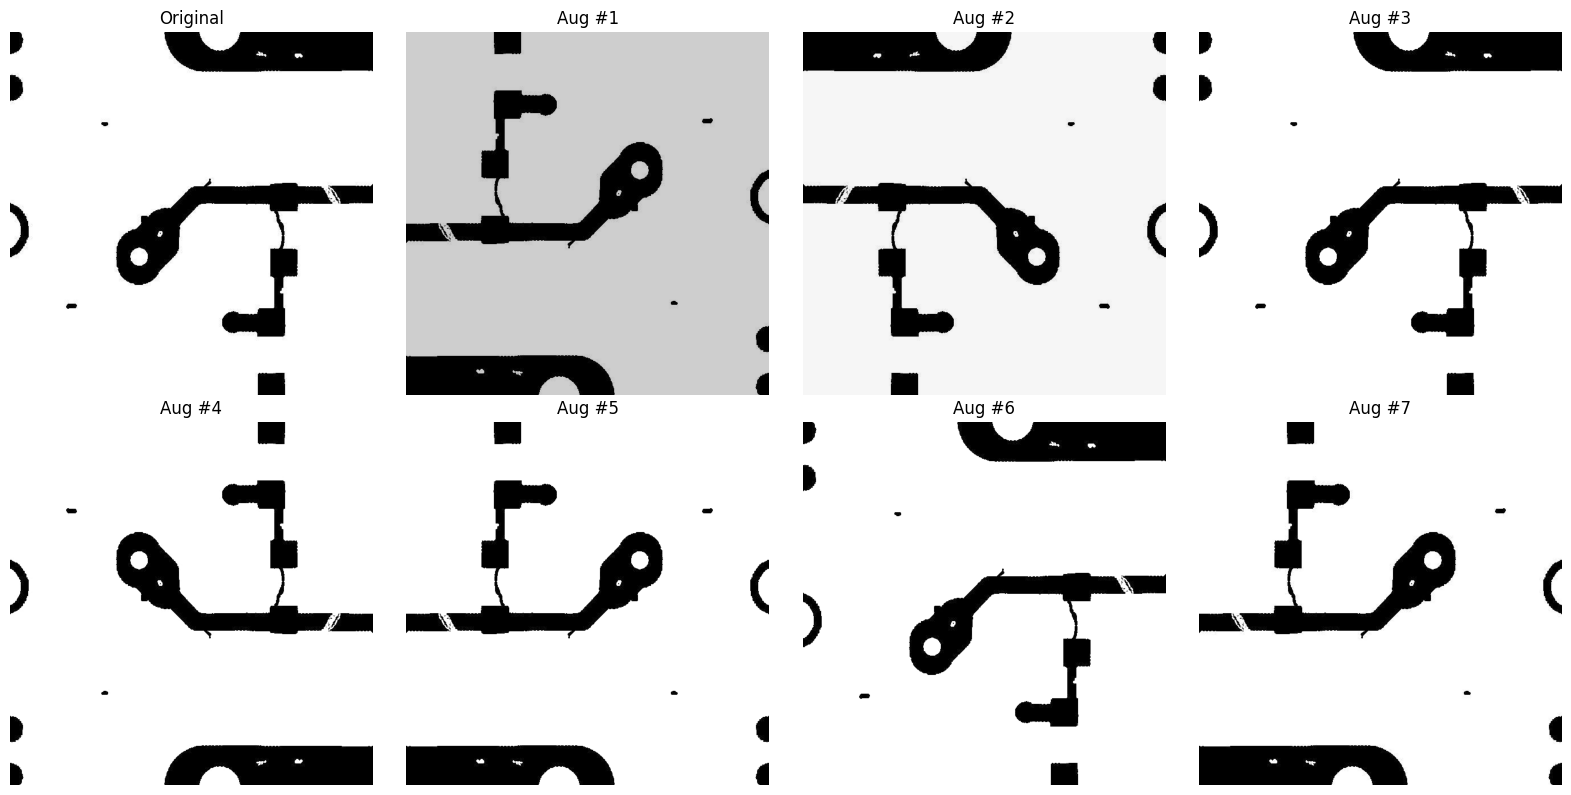

In [9]:
# Quick visual preview via Ultralytics' built-in augmentation pipeline
from ultralytics.data.augment import Compose, RandomHSV, RandomFlip

files = sorted(glob.glob(str(TRAIN_IMG_DIR / '*.jpg')) + glob.glob(str(TRAIN_IMG_DIR / '*.png')))
img = cv2.cvtColor(cv2.imread(files[0]), cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes[0, 0].imshow(img); axes[0, 0].set_title('Original'); axes[0, 0].axis('off')

for i, ax in enumerate(axes.flatten()[1:]):
    aug = img.copy()
    # Random HSV
    hsv = cv2.cvtColor(aug, cv2.COLOR_RGB2HSV).astype(np.int32)
    hsv[..., 0] = (hsv[..., 0] + np.random.randint(-3, 4)) % 180
    hsv[..., 1] = np.clip(hsv[..., 1] * np.random.uniform(0.7, 1.3), 0, 255)
    hsv[..., 2] = np.clip(hsv[..., 2] * np.random.uniform(0.7, 1.3), 0, 255)
    aug = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)
    # Flips
    if random.random() < 0.5: aug = np.fliplr(aug)
    if random.random() < 0.5: aug = np.flipud(aug)
    ax.imshow(aug); ax.set_title(f'Aug #{i+1}'); ax.axis('off')
plt.tight_layout(); plt.show()

## 4. Train YOLOv11s

Two stop conditions are wired in:
1. **Early stopping** via Ultralytics `patience` arg (no improvement on val for N epochs).
2. **Target mAP@50** via a custom callback that stops training as soon as val mAP@50 ≥ `TARGET_MAP50`.

In [13]:
# Custom callback: stop training when val mAP@50 hits the target
TARGET_MAP50 = 0.95   # change to whatever you want as your stop threshold

def stop_on_target_map50(trainer):
    # trainer.metrics is populated after each validation
    metrics = getattr(trainer, 'metrics', None) or {}
    # Ultralytics key is usually 'metrics/mAP50(B)'
    map50 = metrics.get('metrics/mAP50(B)', metrics.get('metrics/mAP50', None))
    if map50 is not None and map50 >= TARGET_MAP50:
        print(f'\n>>> Target reached: mAP@50 = {map50:.4f} >= {TARGET_MAP50}. Stopping training.')
        trainer.stop = True   # signals trainer to stop after this epoch

print(f'Will stop early once val mAP@50 >= {TARGET_MAP50}')

Will stop early once val mAP@50 >= 0.95


In [14]:
# Load YOLOv11s pre-trained weights and attach the callback
model = YOLO('yolo11s.pt')   # downloads automatically if missing
model.add_callback('on_fit_epoch_end', stop_on_target_map50)

results = model.train(
    data=str(DATA_YAML),
    epochs=100,
    imgsz=640,
    batch=16,                # lower to 8 if you hit OOM
    device=0 if torch.cuda.is_available() else 'cpu',
    optimizer='AdamW',
    lr0=0.001,
    lrf=0.01,
    weight_decay=0.0005,
    warmup_epochs=3,
    cos_lr=True,
    patience=20,             # early stopping if no val improvement for 20 epochs
    close_mosaic=10,         # disable mosaic for last 10 epochs
    amp=True,
    seed=42,
    project='runs/deepPCB',
    name='yolov11s_deeppcb',
    exist_ok=True,
    pretrained=True,
    save=True,
    save_period=10,
    plots=True,
    verbose=True,
    **augmentation_cfg,
)

print('\nTraining complete.')

Ultralytics 8.4.60 🚀 Python-3.12.11 torch-2.8.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=deepPCB/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.2, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.01, hsv_s=0.5, hsv_v=0.3, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov11s_deeppcb, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=20, persp

    epoch     time  train/box_loss  train/cls_loss  train/dfl_loss  \
20     21  386.403         1.03959         0.61724         0.99555   
21     22  404.965         1.02175         0.60524         0.98599   
22     23  423.371         1.06758         0.61507         0.99245   
23     24  441.890         1.01319         0.58106         0.98437   
24     25  460.245         0.99192         0.57374         0.97529   

    metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  \
20               0.86692            0.78832           0.88052   
21               0.91214            0.83792           0.93231   
22               0.91688            0.86890           0.94523   
23               0.91293            0.90343           0.94922   
24               0.92212            0.90013           0.95992   

    metrics/mAP50-95(B)  val/box_loss  val/cls_loss  val/dfl_loss    lr/pg0  \
20              0.34878       2.10992       0.98166       1.39346  0.000905   
21              0.43759       

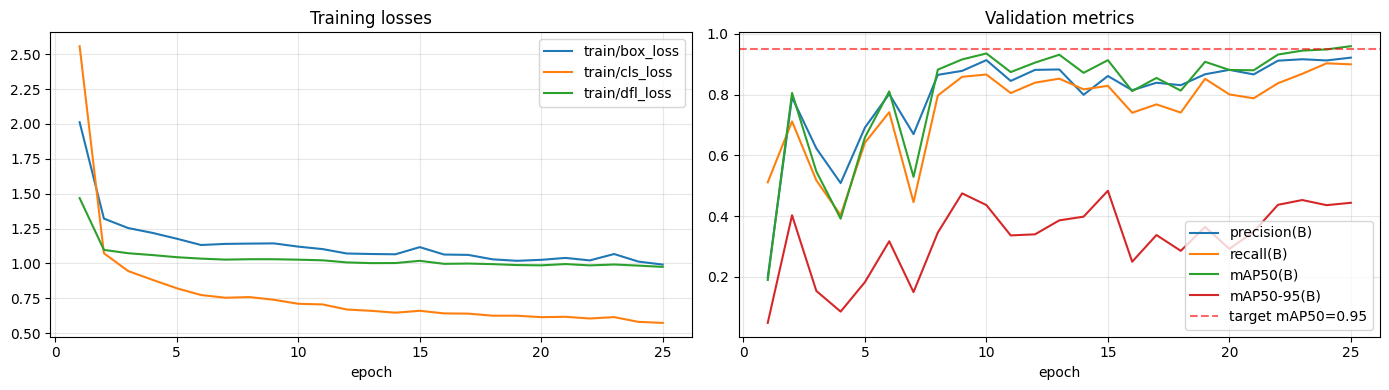

In [18]:
# Plot training curves
run_dir = Path('runs/detect/runs/deepPCB/yolov11s_deeppcb')
csv_path = run_dir / 'results.csv'
if csv_path.exists():
    hist = pd.read_csv(csv_path)
    hist.columns = [c.strip() for c in hist.columns]
    print(hist.tail())
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for col in ['train/box_loss', 'train/cls_loss', 'train/dfl_loss']:
        if col in hist.columns: axes[0].plot(hist['epoch'], hist[col], label=col)
    axes[0].set_title('Training losses'); axes[0].set_xlabel('epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)
    for col in ['metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)']:
        if col in hist.columns: axes[1].plot(hist['epoch'], hist[col], label=col.split('/')[-1])
    axes[1].axhline(TARGET_MAP50, color='red', linestyle='--', alpha=0.6, label=f'target mAP50={TARGET_MAP50}')
    axes[1].set_title('Validation metrics'); axes[1].set_xlabel('epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print(f'No results.csv at {csv_path}')

## 5. Evaluation on the Test Set

In [19]:
best_weights = run_dir / 'weights' / 'best.pt'
print('Best weights:', best_weights, '| exists:', best_weights.exists())

best_model = YOLO(str(best_weights))
test_metrics = best_model.val(
    data=str(DATA_YAML),
    split='test',
    imgsz=640,
    batch=16,
    conf=0.001,
    iou=0.6,
    device=0 if torch.cuda.is_available() else 'cpu',
    plots=True,
    save_json=True,
)

print('\nTest set metrics:')
print(f'  mAP@50      = {test_metrics.box.map50:.4f}')
print(f'  mAP@50-95   = {test_metrics.box.map:.4f}')
print(f'  precision   = {test_metrics.box.mp:.4f}')
print(f'  recall      = {test_metrics.box.mr:.4f}')

# Per-class mAP@50
print('\nPer-class mAP@50:')
for i, name in enumerate(CLASS_NAMES):
    try:
        print(f'  {name:>12}: {test_metrics.box.ap50[i]:.4f}')
    except Exception:
        pass

Best weights: runs/detect/runs/deepPCB/yolov11s_deeppcb/weights/best.pt | exists: True
Ultralytics 8.4.60 🚀 Python-3.12.11 torch-2.8.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO11s summary (fused): 101 layers, 9,415,122 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 63.1±15.2 MB/s, size: 56.4 KB)
val: Scanning /teamspace/studios/this_studio/deepPCB/test/labels... 300 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 300/300 1.4Kit/s 0.2s<0.0s
val: New cache created: /teamspace/studios/this_studio/deepPCB/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 3.3it/s 5.8s0.2s
                   all        300       2011      0.876      0.836      0.921       0.49
                copper        255        302      0.979      0.831      0.959      0.608
             mousebite        258        404      0.891      0.851      0.931      0.483
                  open        266   

--- confusion_matrix.png ---


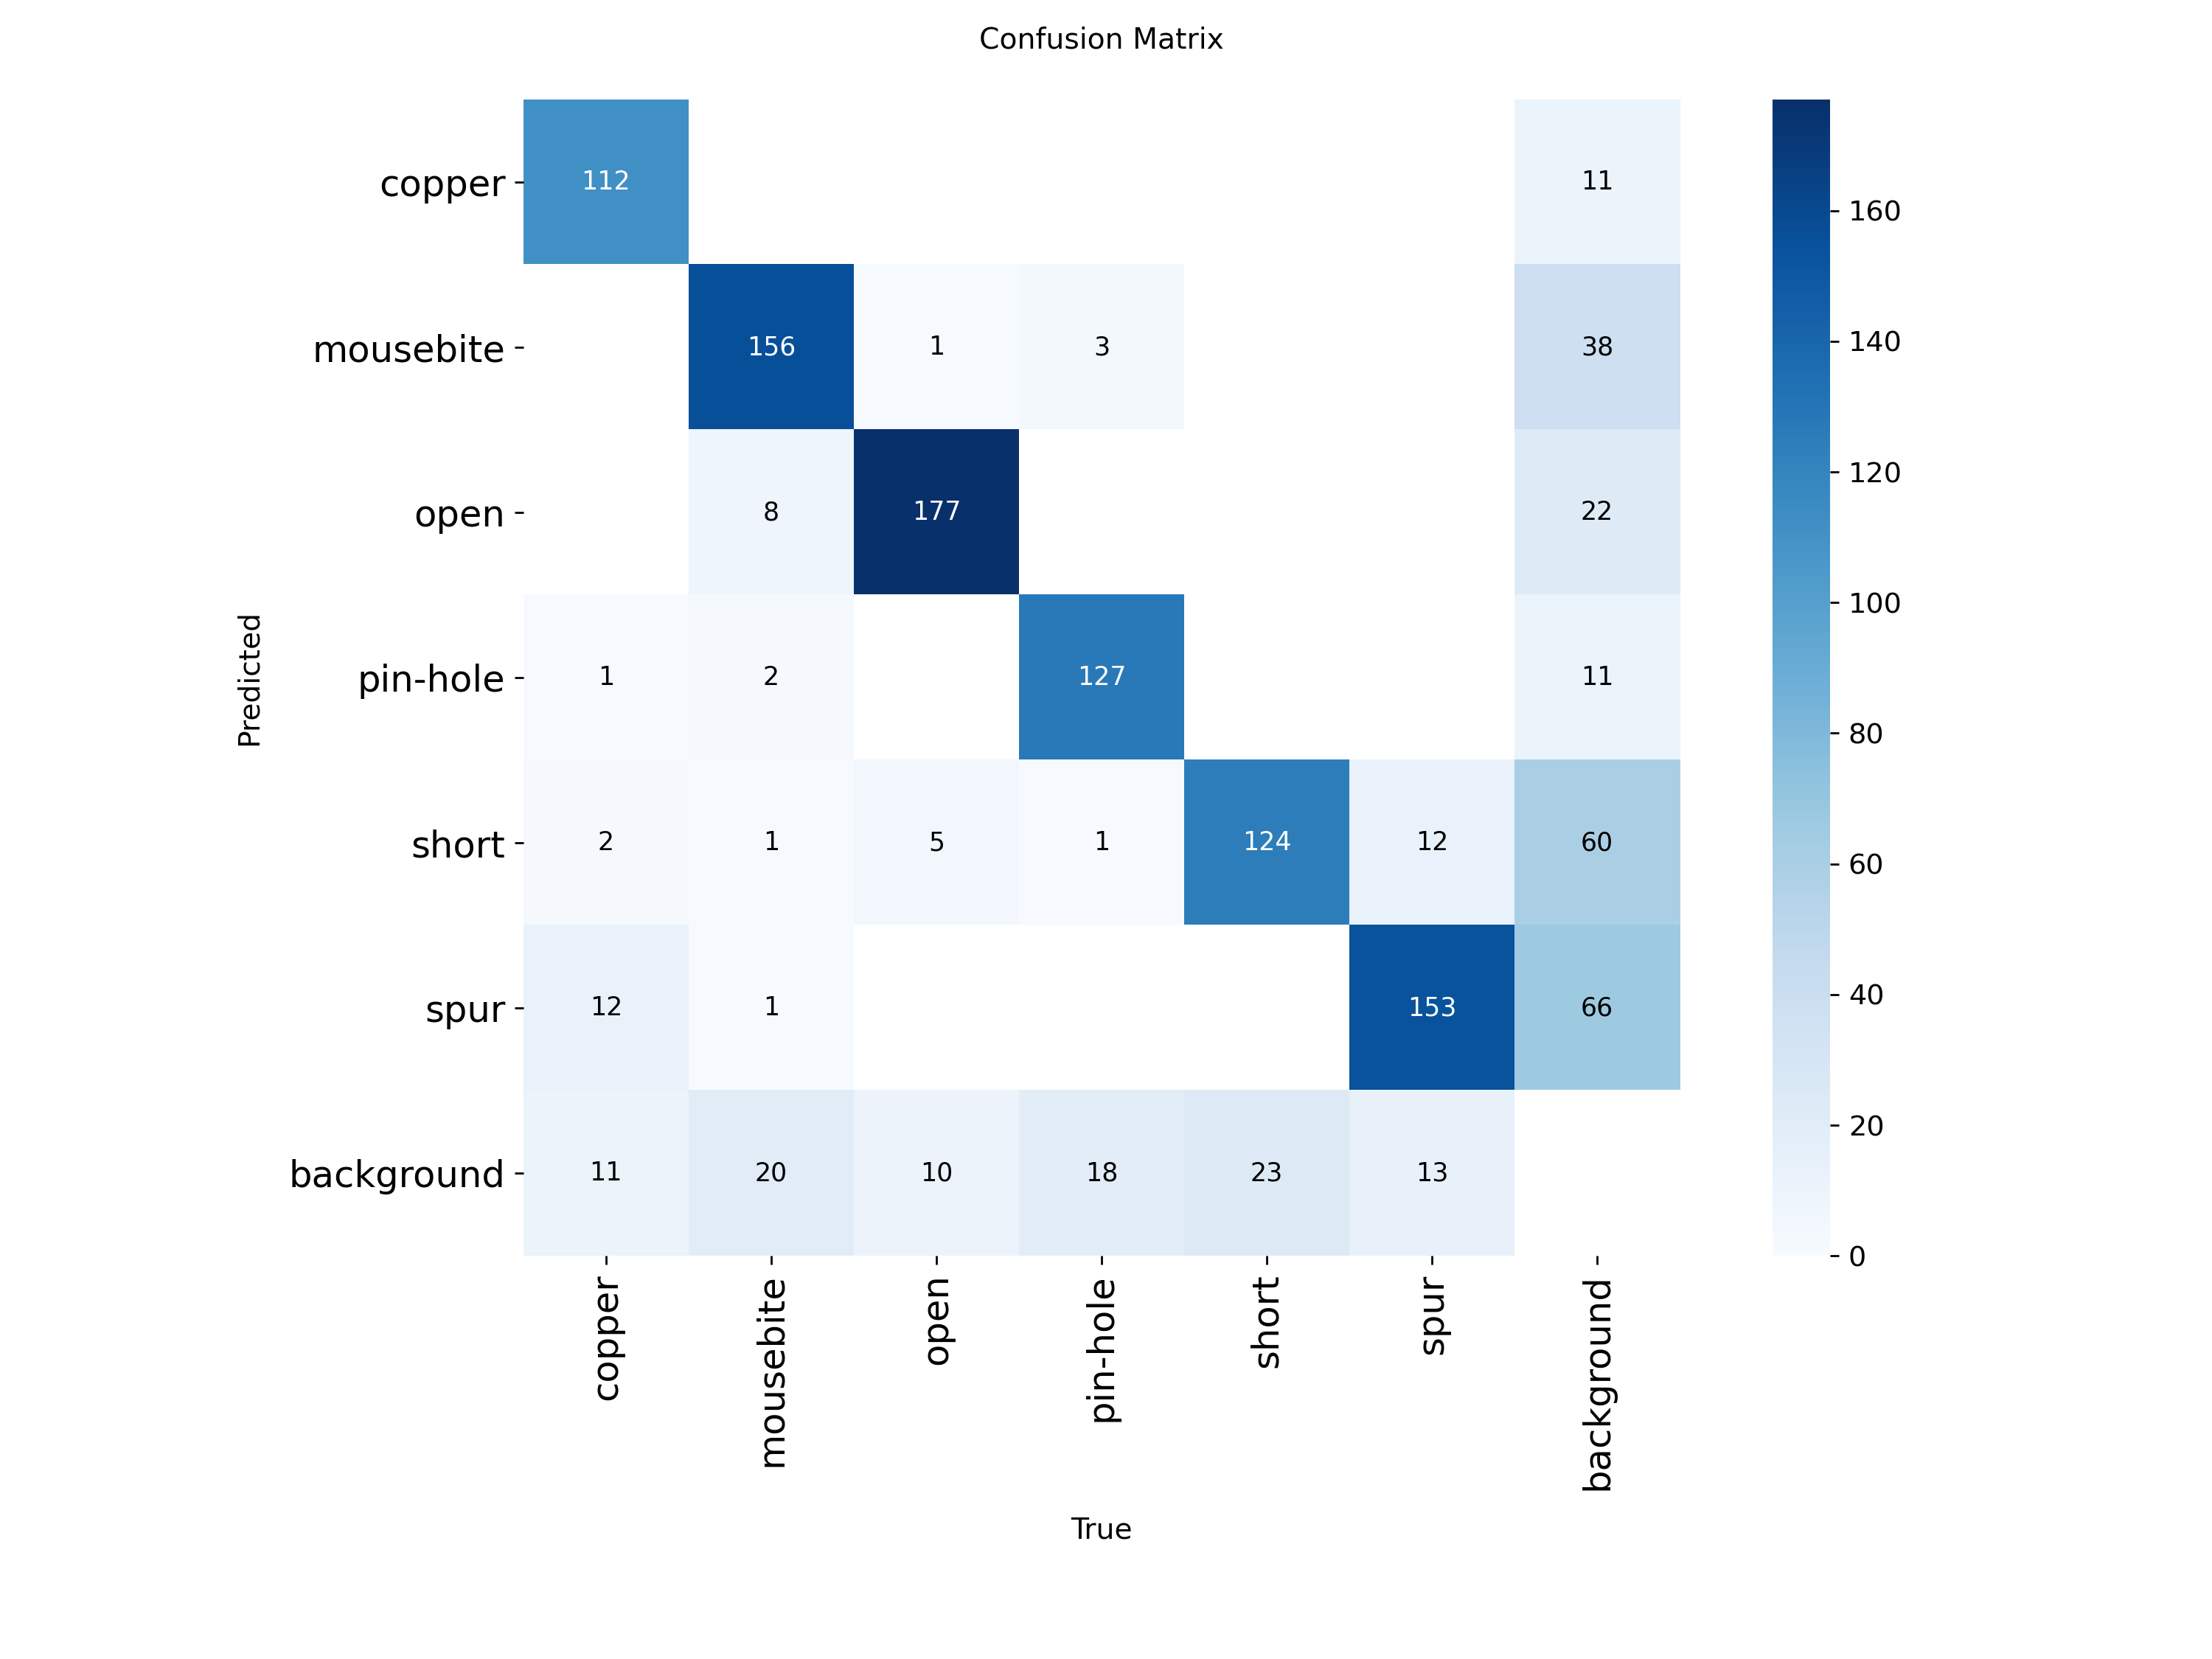

--- results.png ---


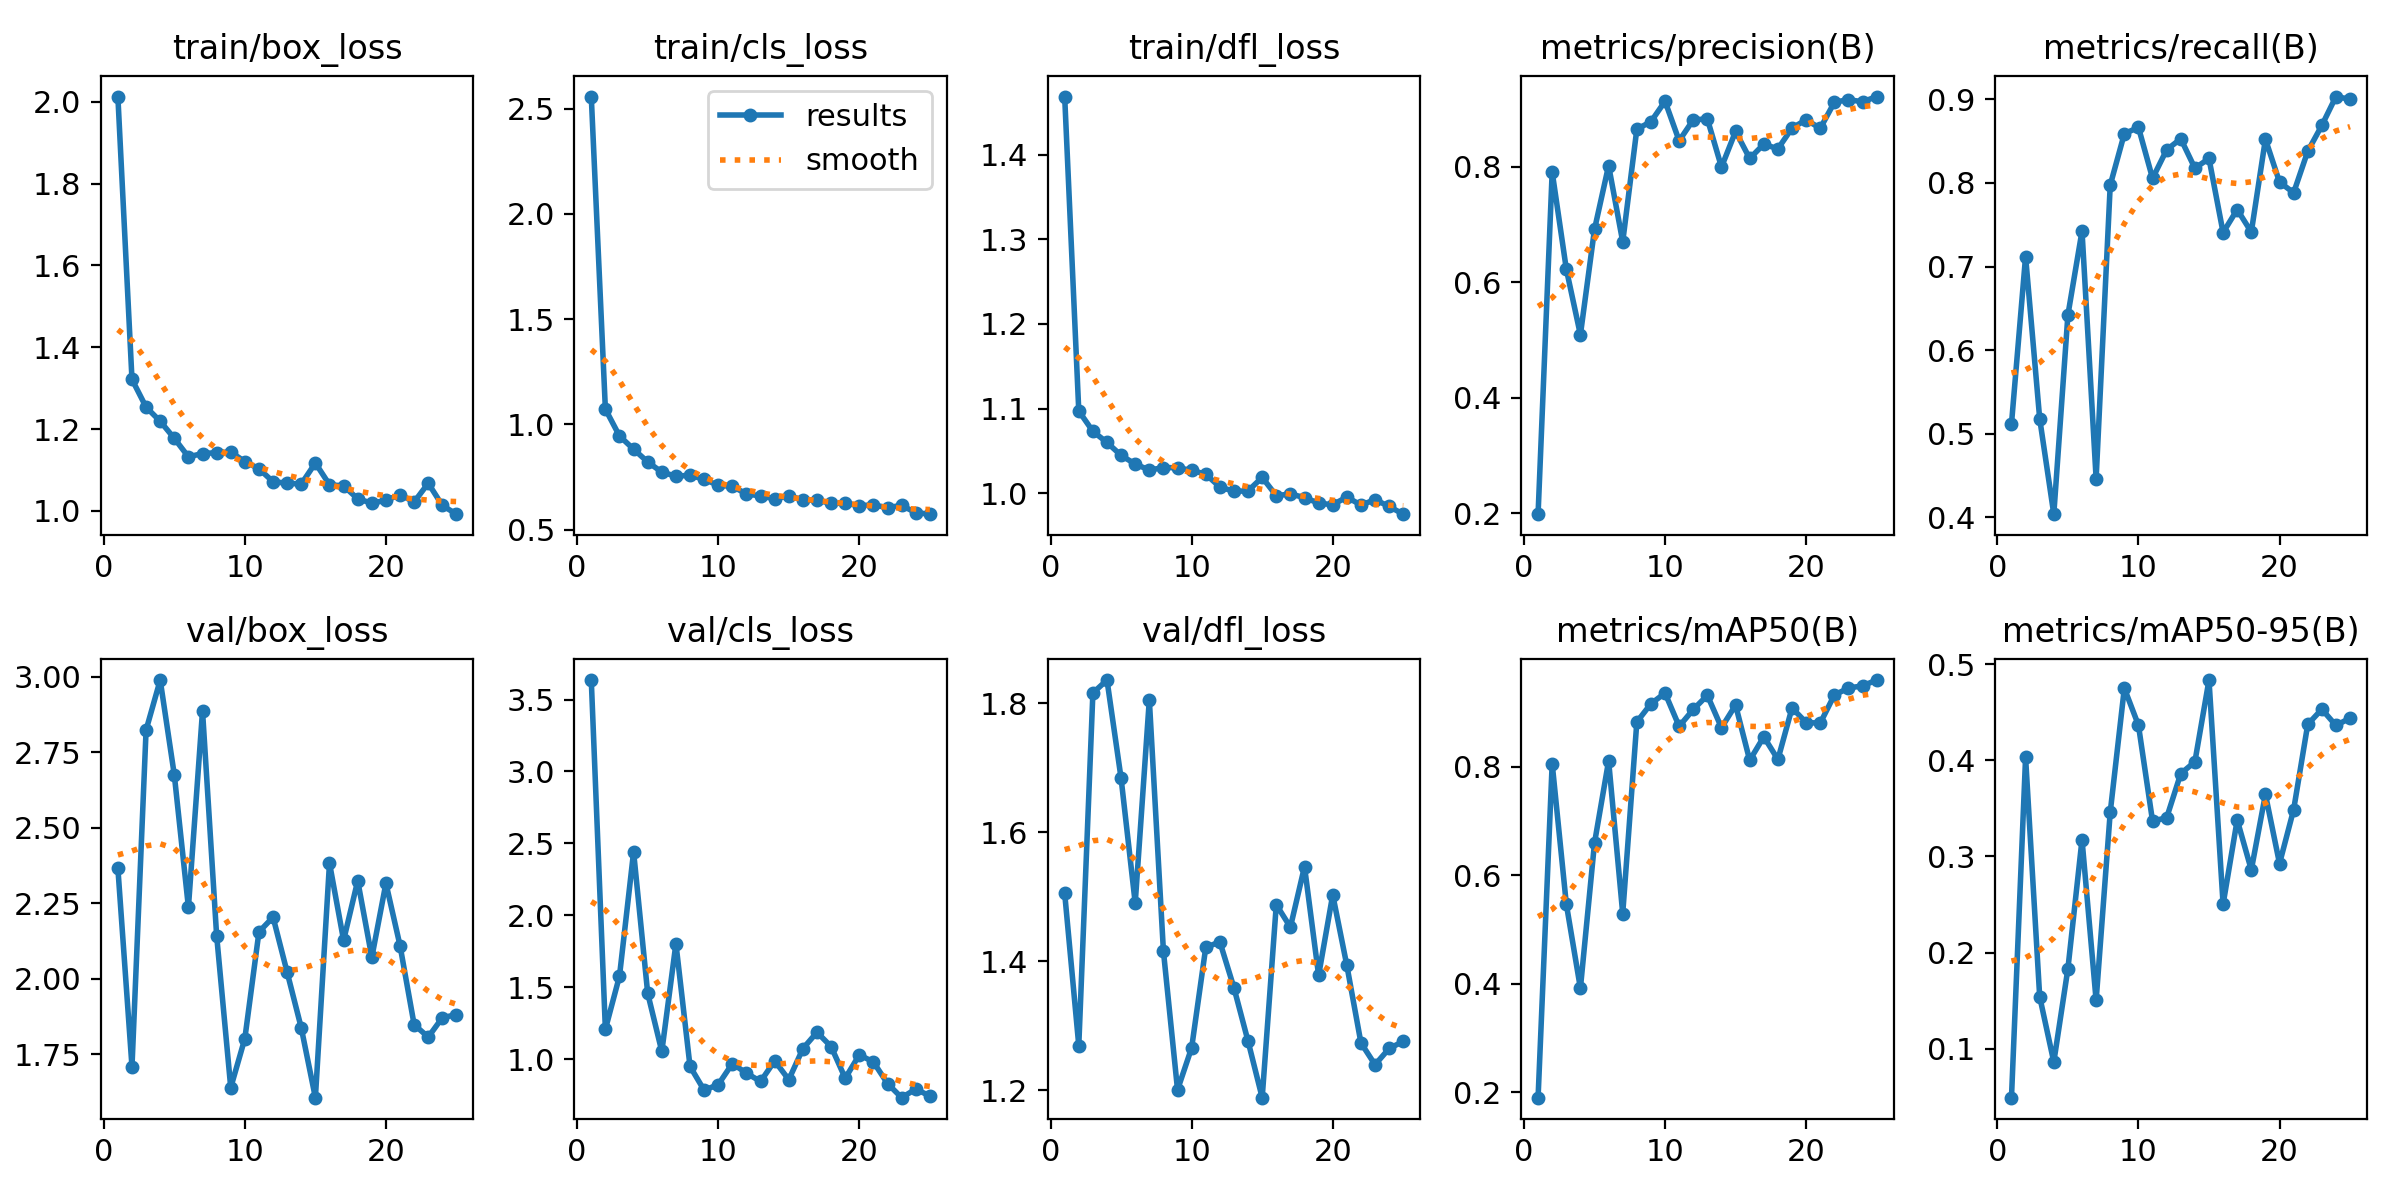

In [20]:
# Show confusion matrix and PR curve if Ultralytics saved them
from IPython.display import Image, display
for fname in ['confusion_matrix.png', 'PR_curve.png', 'F1_curve.png', 'results.png']:
    p = run_dir / fname
    if p.exists():
        print(f'--- {fname} ---')
        display(Image(str(p)))

### Qualitative inference on test images

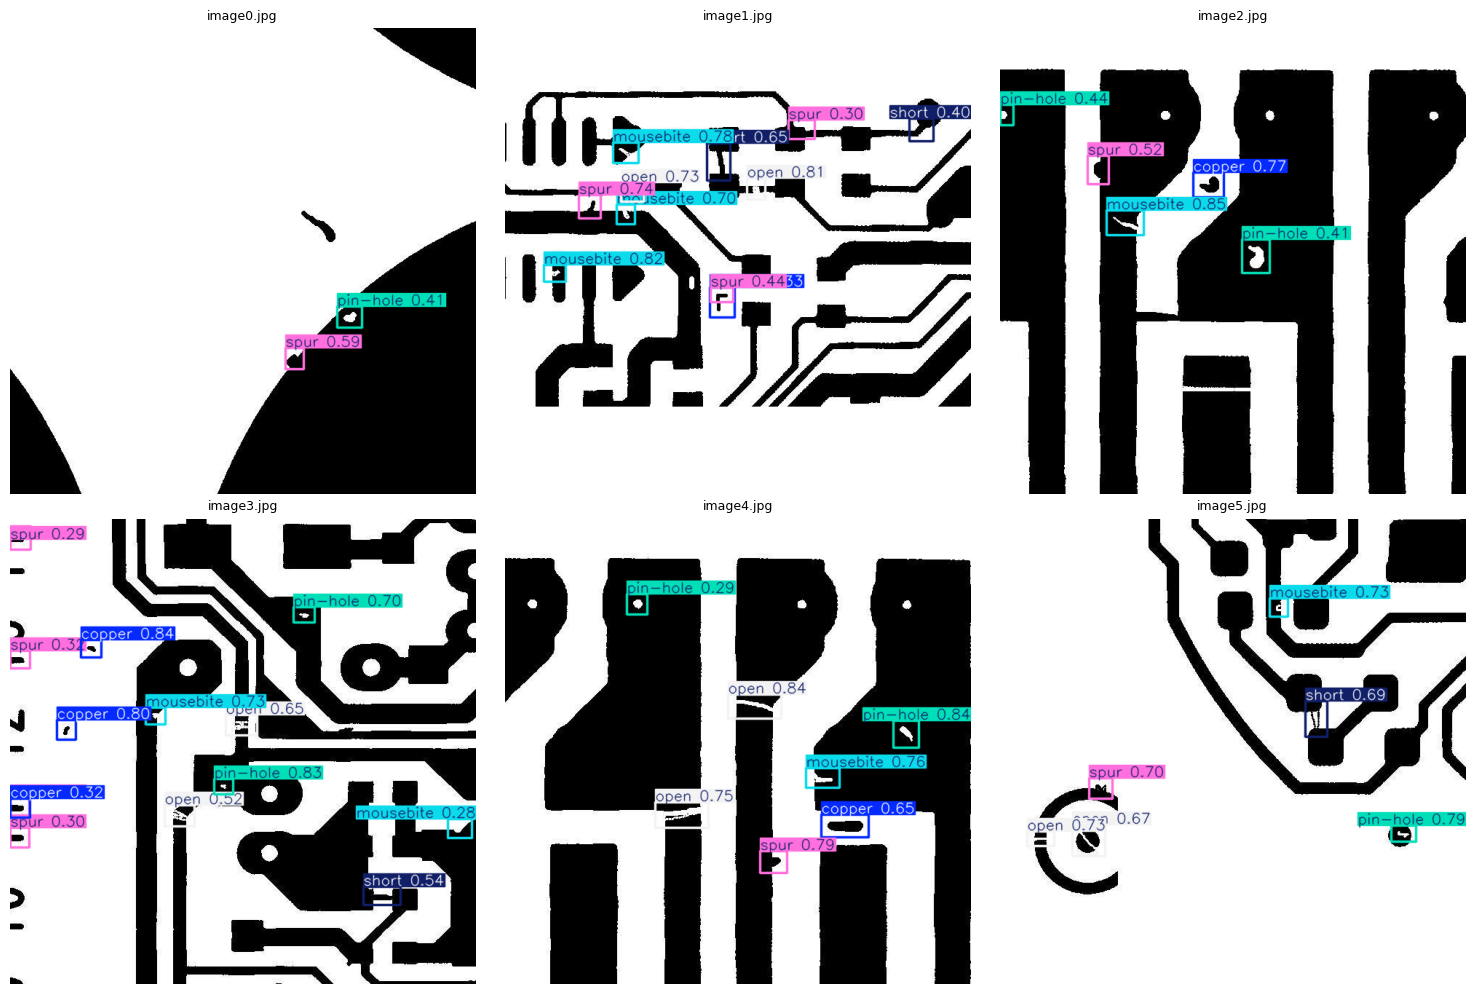

In [21]:
test_files = sorted(glob.glob(str(TEST_IMG_DIR / '*.jpg')) + glob.glob(str(TEST_IMG_DIR / '*.png')))
sample_test = random.sample(test_files, min(6, len(test_files)))

preds = best_model.predict(sample_test, imgsz=640, conf=0.25, iou=0.5, verbose=False)

cols = 3
rows = (len(preds) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 5))
axes = np.array(axes).reshape(-1)
for ax, r in zip(axes, preds):
    plotted = r.plot()  # BGR
    ax.imshow(cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB))
    ax.set_title(Path(r.path).name, fontsize=9); ax.axis('off')
for ax in axes[len(preds):]: ax.axis('off')
plt.tight_layout(); plt.show()

## Done

Trained model + plots are saved under `runs/deepPCB/yolov11s_deeppcb/`. Use `best.pt` for inference:
```python
from ultralytics import YOLO
model = YOLO('runs/deepPCB/yolov11s_deeppcb/weights/best.pt')
model.predict('path/to/image.jpg', save=True, conf=0.25)
```

**Tuning tips if mAP@50 stalls:**
- Increase `imgsz` to 832 or 960 (defects are small)
- Lower `batch` accordingly to fit GPU
- Try `yolo11m.pt` for more capacity
- Raise `copy_paste` to 0.3 if minority classes underperform
- Lower `lr0` to 5e-4 if loss oscillates